In [25]:
# Script to get (V-I) color and E(B-V) reddening in the LMC and SMC

import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
from scipy.optimize import curve_fit

resolution = 3.5 # arcmin
data_pwd = "/Users/mgorski/BADANIA/DATA/LMC_SMC/fields.txt"

result_fname = "./wyniki_tmp.txt"

f_name="/Users/mgorski/BADANIA/PROJECTS/RED_MAP_MC/darek.txt"

print("ok")


ok


In [26]:

# przydatne funkcje

# wczytywanie danych fotometrycznych dla zadanego pola
    #    dane[0]  1         2      3    4        5    6     7    8     9    10   11
    #     ra     dec        V     dV    I       dI    J    dJ    H     dH   K    dK
    #   73.103875 -70.041278 21.752 0.176 21.161 0.339 17.61 0.04 17.07 0.06 16.97 0.17

def load_fields(ra0, dec0, res, fields_path):
    d_min = dec0 - res
    d_max = dec0 + res
    r_min = ra0 - res / np.cos(np.deg2rad(dec0))
    r_max = ra0 + res / np.cos(np.deg2rad(dec0))

    dane = []

    with open(fields_path, 'r') as plik:
        for line in plik:
            fname = line.split()[0]
            rr_min = float(line.split()[1])
            rr_max = float(line.split()[2])
            dd_min = float(line.split()[3])
            dd_max = float(line.split()[4])

            GO = True
            if rr_min > r_max: GO = False
            if rr_max < r_min: GO = False
            if dd_min > d_max: GO = False
            if dd_max < d_min: GO = False    

            if GO:
                with open(fname, 'r') as f:
                    for l in f:
                        ra = float(l.split()[0])
                        dec = float(l.split()[1])
                        if r_min < ra < r_max and d_min < dec < d_max:
                            dane.append(l.split())

    return dane

#funkcja przelicza zapis RA h:m:s na stopnie
#radeg(["3:20:57",]) >> 50.2375

def radeg(ra):
    deg=[]
    for val in ra:
        a,b,c=val.split(":")
        if float(a) < 0: d=float(a)*15.-float(b)/4.-float(c)*15./3600.
        else: d=float(a)*15.+float(b)/4.+float(c)*15./3600.
        deg.append(float(d))
    return deg

#funkcja przelicza zapis DEC stopnie:arcmin:arcsec na stopnie
#decdeg(["-20:2:2",]) >> -20.0338888889

def decdeg(dec):
  deg=[]
  for val in dec:
      a,b,c=val.split(":")
      if float(a) < 0: d=float(a)-float(b)/60.-float(c)/3600.
      else: d=float(a)+float(b)/60.+float(c)/3600.
      deg.append(float(d))
  return deg

# do wyciannia Red Clumpu po kolorach
def colorselectPoly(v,i,poly_x,poly_y):
    v=np.array(v)
    i=np.array(i)   
    xp,yp=v-i,i

    if False:
       obname="cmd"
       plt.figure(obname+" CMD",figsize=(6,6), dpi=100)   
       plt.plot(xp,yp,"b.",alpha=0.5)        
       plt.plot((0.5,0.5),(16.7,18.7),"-k")
       plt.plot((1.5,1.5),(18,20),"-k")
       plt.plot((0.5,1.5),(16.7,18),"-k")
       plt.plot((0.5,1.5),(18.7,20),"-k")
       plt.xlim((-0.5,2.5))
       plt.ylim((20.5,14))
       plt.ylabel("I [mag]")
       plt.xlabel("(V-I) [mag]")
       fname="./"+obname+"_cmd.pdf"
       plt.savefig(fname)
    polygon = np.array(list(zip(poly_x,poly_y)))
    points = np.array(list(zip(xp,yp)))
    path = Path(polygon,codes=None,closed=True)
    maska = path.contains_points(points)    
    v_a=[]
    i_a=[]
    for n,a in enumerate(maska):
        if maska[n]:
           v_a.append(float(v[n]))
           i_a.append(float(i[n]))        
    return v_a,i_a   

# dopasowanie profilu RC
def rc_fit(color,PLOT,NBIN):
    h,tmp = np.histogram(color,bins=NBIN)                
    dx=(tmp[1]-tmp[0])/2
    x=tmp+dx
    x=x[:-1]
    p0 = (np.mean(color),np.std(color),1)
    p, pcov = curve_fit(RCGC, x, h,p0)
    p0 = (p[0], p[1], p[2],0,0,0)
    p, pcov = curve_fit(RC, x, h,p0)
    err = np.sqrt(np.diag(pcov))[0]
    # Compute chi square
    Nexp = RC(x, p[0],p[1],p[2],p[3],p[4],p[5])
    chin=1
    if PLOT : 
       plt.figure(" luminosity histogram", dpi=100)   
       plt.hist(color,NBIN, color="b")                                          
       xa=np.arange(np.min(color),np.max(color),0.01)
       ya=RC(xa, p[0],p[1],p[2],p[3],p[4],p[5])
       plt.plot(xa,ya,"k-")
       plt.ylabel("number of stars")
       plt.xlabel("(V-I) [mag]")
       fname="./rc_lf.pdf"
       plt.savefig(fname)    
    return p[0],err,p[1],p[2]*NBIN,chin

def RC(x,m,s,N,a,b,c):
    x=np.array(x)
    y=(N/(s*2.5066))*np.e**(-1*((x-m)*(x-m))/(2*s*s)) + a + b*(x-m) + c*(x-m)*(x-m)
    return y

def RCGC(x,m,s,N):
    x=np.array(x)
    y=(N/(s*2.5066))*np.e**(-1*((x-m)*(x-m))/(2*s*s)) 
    return y

In [27]:
# wczytywanie wspolrzednych pol do policzenia poczerwieninenia i koloru

lines = []
with open(f_name, 'r', encoding='utf-8') as file0:
    for l in file0:
        tmp = {}
        tmp["ra"] = l.split()[1]
        tmp["dec"] = l.split()[2]
        tmp["line"] = l
        tmp["ebv"] = l.split()[3]
        lines.append(tmp)

print(f'loaded {len(lines)} records')


loaded 38 records


In [28]:
res = resolution / 120. # aby bylo w sekundach luku
fields_path = data_pwd

with open(result_fname, "w") as result_file:

# base file lines + (V-I) err(V-I) sigma Nrc 

    diff = []
    naI_t = []
    erc_t = []
    n_t = []
    ra_t = []
    dec_t = []
    
    for i,ln in enumerate(lines):
        rob = ln["ra"]
        dob = ln["dec"]
        if ":" in rob: rob=radeg([rob,])[0] 
        if ":" in dob: dob=decdeg([dob,])[0]
            
        ra0=float(rob)
        dec0=float(dob)
        
        ebv = float(ln["ebv"])
    
        dane = load_fields(ra0, dec0, res, fields_path)
        if len(dane) > 1:
            dane=list(zip(*dane)) 
                         
            v = dane[2]
            i = dane[4]
            v=np.array(v)
            i=np.array(i)
            v=v.astype(np.float64)
            i=i.astype(np.float64) 
            v,i=colorselectPoly(v,i,[0.6,0.6,1.9,1.9,0.6],[17,19,20,18,17])
            v=np.array(v).astype(np.float64)
            i=np.array(i).astype(np.float64)        
            color=v-i
            c0,ec,sigma,N = 9,9,9,-9
            try: vi_rc,ec,sigma,N,chi=rc_fit(color,False,50)
            except: pass
            #redd_all = (float(vi_rc)-0.838)/1.31759    # all anchors
            redd_naI = (float(vi_rc)-0.854)/1.31759    # Na I

            print(f'{ln["line"].strip()}   {redd_naI:.3f}  {ebv-redd_naI:.3f}  {N:.0f}')
            diff.append(redd_naI-ebv)
            naI_t.append(ebv)
            erc_t.append(redd_naI)
            n_t.append(N)

            ra_t.append(ra0)
            dec_t.append(dec0)
        
            #print(ln["line"].strip(), redd_naI, redd_all, vi_rc, ec, sigma, int(N))
            #print(ln["line"].strip(), redd_naI, ec/1.31759)
    
            #result_file.write(f"{ln['line'].strip()} {redd_naI}\n")
        else:
            pass
            #print(ln["line"].strip(), 99.99)



print(np.mean(diff),np.std(diff))
    

LMC-ECL-01866       073.0636539518700 -68.3195062839300   0.134  *   0.122  0.012  303
LMC-ECL-03160       073.9644933204700 -69.2299793348300   0.109  *   0.112  -0.003  440
LMC-ECL-05430       075.4656687146700 -69.2135558804600   0.108  *   0.103  0.005  771
LMC-ECL-06575       076.1369831210900 -69.3475084561200   0.105  *   0.079  0.026  915
LMC-ECL-09114       077.5818800000000 -68.9700000000000   0.091  *   0.105  -0.014  1015
LMC-ECL-09660       077.9561083776600 -67.0958689063900   0.069  *   0.116  -0.047  166
LMC-ECL-09678       077.9657626314700 -69.5169827022700   0.093  *   0.139  -0.046  1242
LMC-ECL-10567       078.5079500000000 -68.6884470000000   0.097  *   0.101  -0.004  842
J05140595-6915568  078.5247971891800 -69.2657727828400   0.126  *   0.127  -0.001  1219
LMC-ECL-12669       079.8037710000000 -69.1126250000000   0.122  *   0.118  0.004  1381
LMC-ECL-12875       079.9390960000000 -69.7440110000000   0.122  *   0.091  0.031  1798
LMC-ECL-12933       079.973733000

In [10]:
print(np.mean(diff[:-13]),np.std(diff[:-13]))

0.004223188504743566 0.0262233535647198


In [11]:
print(np.mean(diff[26:]),np.std(diff[26:]))

0.04016987634197356 0.04282276802343817


In [18]:
print(np.mean(diff[:20]),np.std(diff[:20]))

0.004223188504743566 0.0262233535647198


In [19]:
print(np.mean(diff[20:26]),np.std(diff[20:26]))

0.03196760099832401 0.031149948337162697


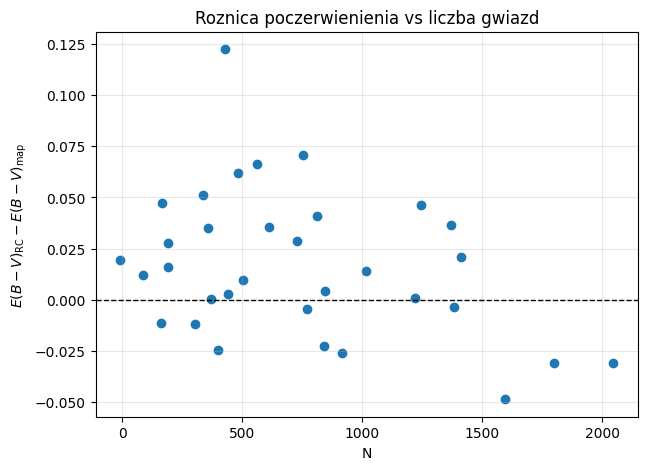

In [12]:
                 
plt.figure(figsize=(7, 5))
plt.axhline(0, color="k", ls="--", lw=1)
plt.scatter(n_t, diff)
#plt.xscale("log")
plt.xlabel("N")
plt.ylabel(r"$E(B-V)_{\rm RC} - E(B-V)_{\rm map}$")
plt.title("Roznica poczerwienienia vs liczba gwiazd")
plt.grid(alpha=0.3)
plt.show()
                 


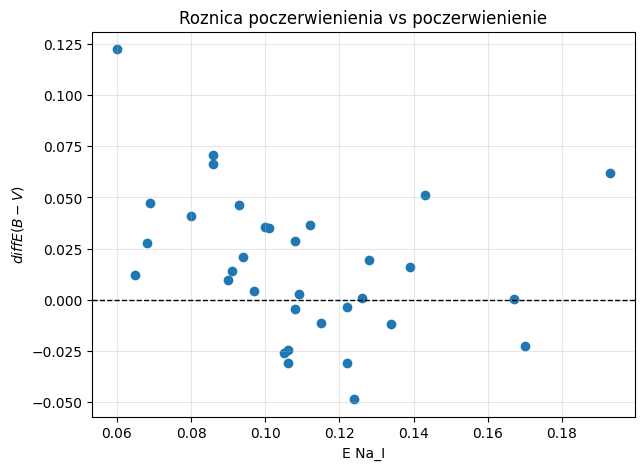

In [13]:
plt.figure(figsize=(7, 5))
plt.axhline(0, color="k", ls="--", lw=1)
plt.scatter(naI_t, diff)
#plt.xscale("log")
plt.xlabel("E Na_I")
plt.ylabel(r"$diff E(B-V)$")
plt.title("Roznica poczerwienienia vs poczerwienienie")
plt.grid(alpha=0.3)
plt.show()

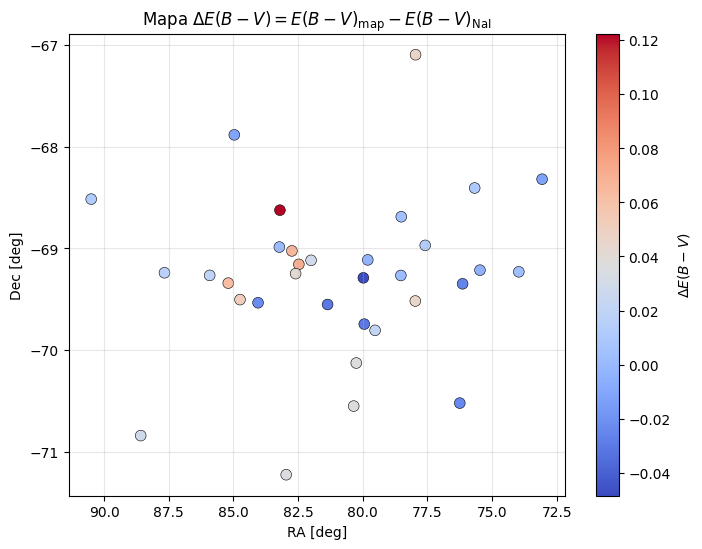

In [15]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(ra_t,dec_t,c=diff,s=60,cmap="coolwarm",edgecolor="k",linewidth=0.4)
plt.gca().invert_xaxis()   # astronomicznie: RA rośnie w lewo
plt.xlabel("RA [deg]")
plt.ylabel("Dec [deg]")
plt.title(r"Mapa $\Delta E(B-V) = E(B-V)_{\rm map} - E(B-V)_{\rm Na I}$")
plt.colorbar(sc, label=r"$\Delta E(B-V)$")
plt.grid(alpha=0.3)
plt.show()